In [ ]:
# Importing Lib :
%matplotlib inline  
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ydata_profiling import ProfileReport

In [52]:
# Loading Dataset :
df = pd.read_csv('../data/breast_cancer.csv')
target = df['target']

In [6]:

# os.makedirs('../outputs',exist_ok=True) # If you haven't created a folder to save the report file it will create one.

profile = ProfileReport(df, explorative=True) # It will create a overall report.

profile.to_file('../outputs/eda_report.html') # We are going to save the 'Report-File' which is a html-file in the outputs folder. 

print('EDA Report saved in outputs folder')

Export report to file: 100%|██████████| 1/1 [00:00<00:00,  7.69it/s]

EDA Report saved in outputs folder


In [20]:
# Basic Info :
print(df.shape)
print(df.info())
print(df.describe())

(569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error

In [18]:
# Checking for Missing Value :
missing_val = df.isnull().sum()
print('Missing_val :\n',missing_val)

# Checking for Duplicate Value :
dupl_val = df.duplicated().sum()
print('Duplicate_val', dupl_val)

Missing_val :
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64
Duplicate_val 0


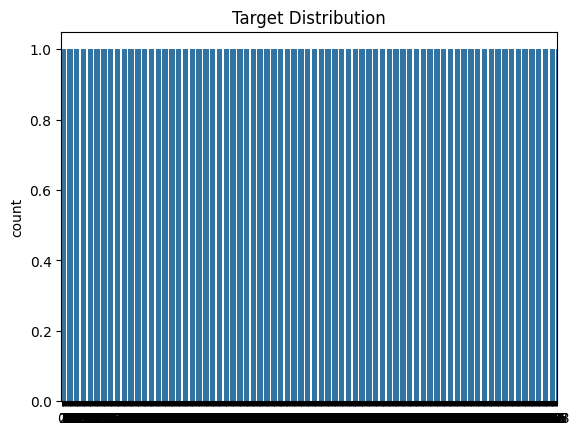

Imbalance Check : target
1    357
0    212
Name: count, dtype: int64


In [29]:
# Target Analysis :
sns.countplot(df['target'])
plt.title('Target Distribution')
plt.show()

# Class Imbalance Check :
imb_check_val = df['target'].value_counts()
print('Imbalance Check :', imb_check_val) # Fix it in the main file

In [39]:
# Selecting the numerical features: 
num_col = df.select_dtypes(include=['int64', 'float64']).columns

# Feature Skew-Check:
skew_val = df[num_col].skew()
print('Skew_val :\n', skew_val)


Skew_val :
 mean radius                0.942380
mean texture               0.650450
mean perimeter             0.990650
mean area                  1.645732
mean smoothness            0.456324
mean compactness           1.190123
mean concavity             1.401180
mean concave points        1.171180
mean symmetry              0.725609
mean fractal dimension     1.304489
radius error               3.088612
texture error              1.646444
perimeter error            3.443615
area error                 5.447186
smoothness error           2.314450
compactness error          1.902221
concavity error            5.110463
concave points error       1.444678
symmetry error             2.195133
fractal dimension error    3.923969
worst radius               1.103115
worst texture              0.498321
worst perimeter            1.128164
worst area                 1.859373
worst smoothness           0.415426
worst compactness          1.473555
worst concavity            1.150237
worst concave po

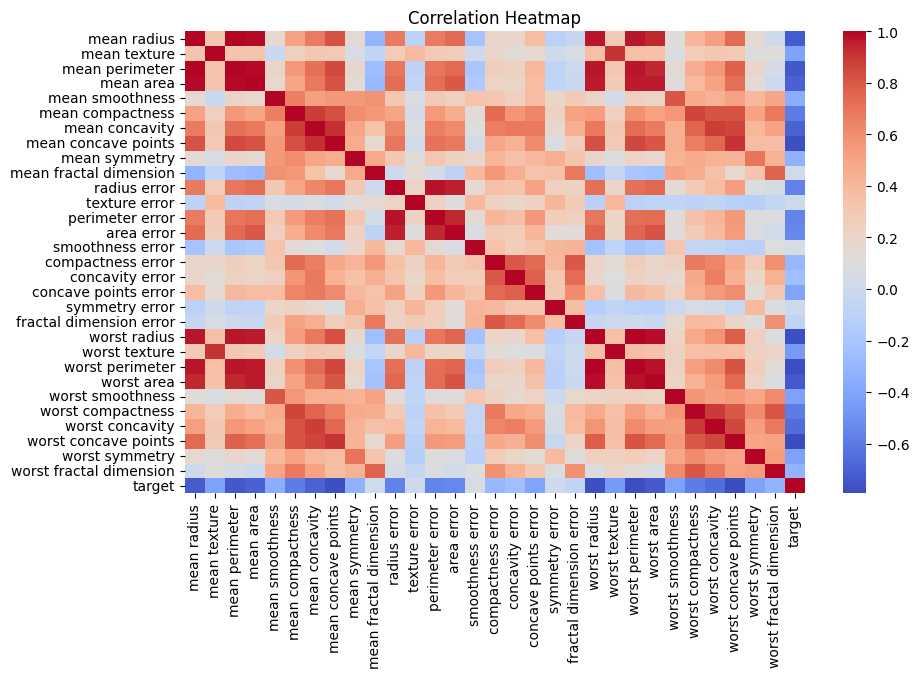

Important-Features : 
 worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64


In [64]:
# Correlation Analysis :
corr = df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Important_features VS Target :
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)

important_features_corr = target_corr[target_corr > 0.3]

print('Important-Features : \n',important_features_corr[:10])
